# The same problem in BayBE

A side comparison to the main Ax workflow. [BayBE](https://emdgroup.github.io/baybe/stable/) is another Bayesian optimization library built on BoTorch, designed around experimental campaigns. This notebook gives BayBE and Ax the same 10 lab measurements, the same search space and the same thresholds, and compares the batches they propose next.

It replaces an earlier version written for BayBE 0.7. That version could only combine the two objectives into one desirability score, because BayBE had no multi-objective (Pareto) mode yet; current BayBE has one, so both approaches are shown here.

Written for BayBE 0.15 (`pip install -e ".[baybe]"` from the repository root).

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from baybe import Campaign, active_settings
from baybe.acquisition import qLogNEHVI
from baybe.objectives import DesirabilityObjective, ParetoObjective
from baybe.parameters import NumericalContinuousParameter
from baybe.recommenders import BotorchRecommender, TwoPhaseMetaRecommender
from baybe.searchspace import SearchSpace
from baybe.targets import NumericalTarget
from ax.utils.common.logger import set_stderr_log_level

from niw_bo import attach_experiments, build_client, load_experiments
from niw_bo.campaign import PARAMETER_NAMES
from niw_bo.config import BATCH_SIZE, OBJECTIVE_THRESHOLDS, OBJECTIVES, PARAMETERS
from niw_bo.plotting import AXIS, GRID, INK, INK_SECONDARY, MUTED, SERIES, label

warnings.filterwarnings("ignore", category=FutureWarning)
set_stderr_log_level(logging.WARNING)
SEED = 0
active_settings.random_seed = SEED
N_RESTARTS = 5  # BayBE's default is 10; fewer keeps this notebook to about a minute per batch

## 1. Data

Only the lab measurements (`source == "lab"`); the illustrative rows in the table are excluded.

In [2]:
lab = load_experiments("../data/experiments.csv", include_illustrative=False)
lab[[*PARAMETER_NAMES, *OBJECTIVES]]

,tungstate_concentration,current_density,deposition_time,pH,overpotential,overpotential_slope
0,0.05,10,500,5.0,-358.0,0.000150
1,0.05,50,300,6.0,-319.0,0.000066
2,0.10,10,300,7.0,-377.0,0.000100
3,0.10,10,600,8.0,-319.0,-0.000518
4,0.10,50,600,7.5,-286.0,0.000080
5,0.10,100,600,10.0,-312.0,0.000029
6,0.10,50,400,6.5,-309.0,-0.000057
7,0.10,30,600,8.5,-290.0,0.001656
8,0.15,10,600,9.5,-329.0,0.000131
9,0.15,50,300,9.5,-305.0,-0.000064


## 2. Search space

The same bounds as `src/niw_bo/config.py`. All four parameters are treated as continuous, and the recommendations are rounded afterwards to what the lab uses: whole numbers for current density and deposition time, steps of 0.5 for pH.

BayBE can model pH as a discrete parameter directly (`NumericalDiscreteParameter` with the 11 allowed values). That turns the problem into a hybrid search space, which BayBE optimizes by repeating the continuous optimization for the discrete values; here that took about three times as long per recommended point, and for a single point it proposed the same pH as the rounded continuous version.

In [3]:
parameters = [
    NumericalContinuousParameter(p.name, tuple(map(float, p.bounds))) for p in PARAMETERS
]
searchspace = SearchSpace.from_product(parameters)


def to_lab_grid(recommendation: pd.DataFrame) -> pd.DataFrame:
    """Round BayBE's continuous recommendations to the values used in the lab."""
    out = recommendation[PARAMETER_NAMES].reset_index(drop=True).copy()
    out["current_density"] = out["current_density"].round().astype(int)
    out["deposition_time"] = out["deposition_time"].round().astype(int)
    out["pH"] = (out["pH"] * 2).round() / 2
    return out

## 3. Two ways to handle two objectives

### 3a. Pareto objective

`ParetoObjective` models each target separately and looks for the set of best trade-offs, like Ax does. The default acquisition function is the same qLogNEHVI that Ax uses. Its reference point is set to the Ax objective thresholds (overpotential −350 mV, slope −0.001), so both libraries score hypervolume relative to the same corner; left unset, BayBE derives one from the data.

In [4]:
thresholds = [float(t.split(">=")[1]) for t in OBJECTIVE_THRESHOLDS]
pareto_campaign = Campaign(
    searchspace=searchspace,
    objective=ParetoObjective([NumericalTarget(name) for name in OBJECTIVES]),  # maximized
    recommender=TwoPhaseMetaRecommender(
        recommender=BotorchRecommender(
            acquisition_function=qLogNEHVI(reference_point=thresholds),
            n_restarts=N_RESTARTS,
        )
    ),
)
pareto_campaign.add_measurements(lab[[*PARAMETER_NAMES, *OBJECTIVES]])
baybe_pareto = to_lab_grid(pareto_campaign.recommend(batch_size=BATCH_SIZE))
baybe_pareto

,tungstate_concentration,current_density,deposition_time,pH
0,0.078203,36,600,9.0
1,0.120221,35,600,8.0
2,0.103461,48,600,9.0


### 3b. Desirability objective (the approach in the original notebook)

`DesirabilityObjective` maps each target onto a 0–1 desirability and combines them into a single score, by default with a geometric mean of equal weights. The ramps below use the same bounds as before: overpotential from −400 mV (0) to 0 mV (1), slope from −0.05 (0) to +0.05 (1).

This turns the problem into single-objective optimization of one fixed trade-off. Its optimum is a Pareto-optimal point, but only the one that the weights and ramps favour; changing them moves it along the front. A Pareto objective instead tries to improve the whole front at once, which is what the original note ("connection to the Pareto front?") was asking for.

The slope ramp is very wide compared with the measured slopes (all within ±0.002), so the slope barely changes the desirability score: in practice this objective optimizes the overpotential alone.

In [5]:
desirability_campaign = Campaign(
    searchspace=searchspace,
    objective=DesirabilityObjective(
        [
            NumericalTarget.normalized_ramp("overpotential", cutoffs=(-400, 0)),
            NumericalTarget.normalized_ramp("overpotential_slope", cutoffs=(-0.05, 0.05)),
        ]
    ),
    recommender=TwoPhaseMetaRecommender(recommender=BotorchRecommender(n_restarts=N_RESTARTS)),
)
desirability_campaign.add_measurements(lab[[*PARAMETER_NAMES, *OBJECTIVES]])
baybe_desirability = to_lab_grid(desirability_campaign.recommend(batch_size=BATCH_SIZE))
baybe_desirability

,tungstate_concentration,current_density,deposition_time,pH
0,0.089295,46,600,9.0
1,0.139903,50,600,8.5
2,0.050000,42,600,8.5


## 4. Ax on the same data

The same call as in the main notebook, restricted to the lab rows.

In [6]:
client = build_client(seed=SEED)
attach_experiments(client, lab)
ax_batch = pd.DataFrame(client.get_next_trials(max_trials=BATCH_SIZE).values())[PARAMETER_NAMES]
ax_batch

,tungstate_concentration,current_density,deposition_time,pH
0,0.050000,34,600,9.0
1,0.068569,46,600,9.5
2,0.142484,34,596,8.0


## 5. Comparison

In [7]:
batches = {
    "Ax (qLogNEHVI)": ax_batch,
    "BayBE Pareto (qLogNEHVI)": baybe_pareto,
    "BayBE desirability (qLogEI)": baybe_desirability,
}
pd.concat(batches, names=["method", "point"]).round({"tungstate_concentration": 3})

tungstate_concentration  current_density  \
method                      point                                             
Ax (qLogNEHVI)              0                        0.050               34   
                            1                        0.069               46   
                            2                        0.142               34   
BayBE Pareto (qLogNEHVI)    0                        0.078               36   
                            1                        0.120               35   
                            2                        0.103               48   
BayBE desirability (qLogEI) 0                        0.089               46   
                            1                        0.140               50   
                            2                        0.050               42   

                                   deposition_time   pH  
method                      point                        
Ax (qLogNEHVI)              0                  600  9.0  
                            1                  600  9.5  
                            2                  596  8.0  
BayBE Pareto (qLogNEHVI)    0                  600  9.0  
                            1                  600  8.0  
                            2                  600  9.0  
BayBE desirability (qLogEI) 0                  600  9.0  
                            1                  600  8.5  
                            2                  600  8.5

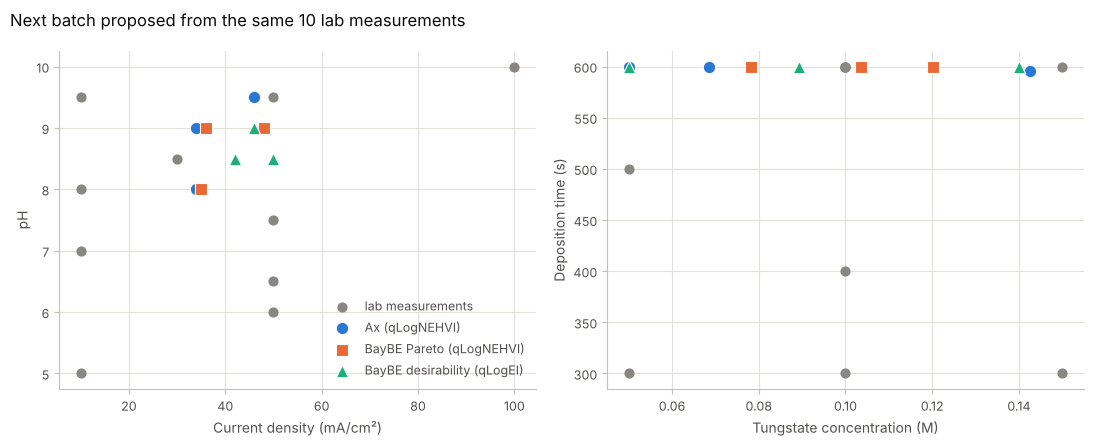

In [8]:
pairs = [("current_density", "pH"), ("tungstate_concentration", "deposition_time")]
markers = ["o", "s", "^"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(lab[x], lab[y], s=40, color=MUTED, label="lab measurements", zorder=2)
    for (name, batch), color, marker in zip(batches.items(), SERIES, markers):
        ax.scatter(batch[x], batch[y], s=80, color=color, marker=marker,
                   edgecolors="white", linewidths=0.8, label=name, zorder=3)
    ax.set_xlabel(label(x), color=INK_SECONDARY)
    ax.set_ylabel(label(y), color=INK_SECONDARY)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=AXIS, labelcolor=INK_SECONDARY, labelsize=9)
axes[0].legend(frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
fig.suptitle("Next batch proposed from the same 10 lab measurements",
             x=0.01, ha="left", color=INK, fontsize=12)
fig.tight_layout()

**What this shows.** With only 10 measurements, the three proposals land in the same region: deposition time at or within 4 s of the 600 s upper limit in all nine points, current density between 34 and 50 mA/cm², and pH between 8 and 9.5. That is next to the two lab points on the measured Pareto front, trial 4 (best overpotential: 50 mA/cm², 600 s, pH 7.5) and trial 7 (best slope: 30 mA/cm², 600 s, pH 8.5). The batches differ mainly in tungstate concentration, which the models find has little effect, so that is where they spread their points.

Two practical readings: the choice of library matters less here than the data, and every method pushing deposition time to its upper bound suggests extending that range, if the process allows.

The desirability batch looks similar to the Pareto ones only because the overpotential dominates its score (see 3b); with a narrower slope ramp it would move.


## 6. Saving a campaign

A BayBE campaign, including its measurements, serializes to JSON; the DataFrames inside are stored in a binary format, so the file is not human-readable. As with Ax, the CSV in `data/` remains the readable record.

In [9]:
restored = Campaign.from_json(pareto_campaign.to_json())
restored.measurements[[*PARAMETER_NAMES, *OBJECTIVES]].shape

(10, 6)

## What changed since the BayBE 0.7 version

| BayBE 0.7 | BayBE 0.15 |
|---|---|
| `Objective(mode="DESIRABILITY", targets=..., combine_func="GEOM_MEAN")` | `DesirabilityObjective(targets)` (geometric mean is the default) |
| no multi-objective option | `ParetoObjective(targets)` with qLogNEHVI |
| `NumericalTarget(name, mode="MAX", bounds=..., transformation="LINEAR")` | `NumericalTarget(name)` (maximized by default), or `NumericalTarget.normalized_ramp(name, cutoffs=...)` for a 0–1 ramp; the old form still works but is deprecated |
| `SequentialGreedyRecommender(acquisition_function_cls="qEI")` | `BotorchRecommender(acquisition_function=qLogNEHVI(...))` |
| `NaiveHybridRecommender` | removed; `BotorchRecommender` handles hybrid spaces |
| `TwoPhaseStrategy(initial_recommender, recommender)`, `Campaign(searchspace, objective, strategy)` | `TwoPhaseMetaRecommender(...)`, `Campaign(searchspace, objective, recommender)` |
| tolerances on discrete parameters to match measured values | continuous parameters, rounded after recommendation |